In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
# 1. PREPARAÇÃO E MERGE DE DADOS

In [37]:
OCORRENCIAS = r'C:\Users\lucas.emoura\Documents\PastaLucas\aula01_UC2\aula02\03.BaseDPEvolucaoMensalCisp.csv'
DP = r'C:\Users\lucas.emoura\Documents\PastaLucas\aula01_UC2\aula02\08.DP.csv'

df_ocorrencias = pd.read_csv(
    OCORRENCIAS,
    sep=';',
    encoding='iso-8859-1'
)

df_DP = pd.read_csv(
    DP
)

df_DP.head(10)

,codDP,nome,endereco
0,1,001ª DP - Praça da República,"Av. Presidente Vargas, 1100 - Centro, Rio de J..."
1,4,004ª DP - Praça da República,"Av. Presidente Vargas, 1100 - Centro, Rio de J..."
2,5,005ª DP - Mem de Sá,"Avenida Gomes Freire, 320 - Centro, Rio de Jan..."
3,6,006ª DP - Cidade Nova,"Rua Professor Clementino Fraga, 77 - Centro, R..."
4,7,007ª DP - Santa Teresa,"Rua Francisco de Castro, 5 - Santa Teresa, Rio..."
5,9,009ª DP - Catete,"Rua Pedro Américo, 1 - Catete, Rio de Janeiro ..."
6,10,010ª DP - Botafogo,"Rua Bambina, 140 - Botafogo, Rio de Janeiro - ..."
7,11,011ª DP - Rocinha,"Rua Bertha Lutz, 80 - Gávea, Rio de Janeiro - ..."
8,12,012ª DP - Copacabana,"Rua Hilário de Gouveia, 102 - Copacabana, Rio ..."
9,13,013ª DP - Ipanema,"Avenida Nossa Senhora de Copacabana, 1260 - Co..."


In [38]:
df_merge = df_ocorrencias.merge(
    df_DP, # com quem juntar
    how='left', # como juntar (inner, left, outer)
    right_on='codDP', # coluna da tabela a direita (com quem juntar)
    left_on='cisp' # coluna da tabela a esquerda (quem chamou)
)
df_merge.columns

Index(['cisp', 'mes', 'ano', 'mes_ano', 'aisp', 'risp', 'munic', 'mcirc',
       'regiao', 'hom_doloso', 'lesao_corp_morte', 'latrocinio', 'cvli',
       'hom_por_interv_policial', 'letalidade_violenta', 'tentat_hom',
       'lesao_corp_dolosa', 'estupro', 'hom_culposo', 'lesao_corp_culposa',
       'roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_rua',
       'roubo_veiculo', 'roubo_carga', 'roubo_comercio', 'roubo_residencia',
       'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque',
       'roubo_apos_saque', 'roubo_bicicleta', 'outros_roubos', 'total_roubos',
       'furto_veiculos', 'furto_transeunte', 'furto_coletivo', 'furto_celular',
       'furto_bicicleta', 'outros_furtos', 'total_furtos', 'sequestro',
       'extorsao', 'sequestro_relampago', 'estelionato', 'apreensao_drogas',
       'posse_drogas', 'trafico_drogas', 'apreensao_drogas_sem_autor',
       'recuperacao_veiculos', 'apf', 'aaapai', 'cmp', 'cmba', 'ameaca',
       'pessoas_desaparecidas'

In [39]:
df_roubo_celular = df_merge[[
    'cisp', 'nome', 'roubo_transeunte', 'roubo_celular', 'codDP', 'ano'
]]
df_roubo_celular

,cisp,nome,roubo_transeunte,roubo_celular,codDP,ano
0,1,001ª DP - Praça da República,26,32,1.0,2003
1,4,004ª DP - Praça da República,25,14,4.0,2003
2,5,005ª DP - Mem de Sá,26,34,5.0,2003
3,6,006ª DP - Cidade Nova,14,20,6.0,2003
4,7,007ª DP - Santa Teresa,4,1,7.0,2003
...,...,...,...,...,...,...
34843,159,159ª DP - Cachoeira de Macacu,1,0,159.0,2024
34844,165,165ª DP - Mangaratiba,0,0,165.0,2024
34845,166,166ª DP - Angra dos Reis,2,1,166.0,2024
34846,167,167ª DP - Paraty,2,2,167.0,2024


In [40]:
df_roubo_celular_por_dp = (
    df_roubo_celular.groupby('nome')['roubo_celular']
    .sum().reset_index()
)
df_roubo_celular_por_dp

,nome,roubo_celular
0,001ª DP - Praça da República,3989
1,004ª DP - Praça da República,4332
2,005ª DP - Mem de Sá,6912
3,006ª DP - Cidade Nova,2578
4,007ª DP - Santa Teresa,623
...,...,...
132,159ª DP - Cachoeira de Macacu,72
133,165ª DP - Mangaratiba,182
134,166ª DP - Angra dos Reis,559
135,167ª DP - Paraty,82


In [41]:
df_roubo_celular_por_ano = (
    df_roubo_celular.groupby('ano')['roubo_celular']
    .sum().reset_index()
)
df_roubo_celular_por_ano

,ano,roubo_celular
0,2003,12760
1,2004,11084
2,2005,6913
3,2006,7962
4,2007,7592
5,2008,8614
6,2009,8499
7,2010,6988
8,2011,5391
9,2012,4362


In [42]:
df_roubo_transeunte_por_dp = (
    df_roubo_celular.groupby('nome')['roubo_transeunte']
    .sum().reset_index()
)
df_roubo_transeunte_por_dp

,nome,roubo_transeunte
0,001ª DP - Praça da República,15243
1,004ª DP - Praça da República,18122
2,005ª DP - Mem de Sá,29650
3,006ª DP - Cidade Nova,11883
4,007ª DP - Santa Teresa,4691
...,...,...
132,159ª DP - Cachoeira de Macacu,480
133,165ª DP - Mangaratiba,540
134,166ª DP - Angra dos Reis,2005
135,167ª DP - Paraty,380


In [43]:
df_roubo_transeunte_por_ano = (
    df_roubo_celular.groupby('ano')['roubo_transeunte']
    .sum().reset_index()
)
df_roubo_transeunte_por_ano

,ano,roubo_transeunte
0,2003,17884
1,2004,22256
2,2005,36080
3,2006,46340
4,2007,59494
5,2008,68039
6,2009,71066
7,2010,63346
8,2011,54678
9,2012,49560


In [44]:
df_roubo_transeunte_decrescente = (
    df_roubo_celular.groupby('nome')['roubo_transeunte']
    .sum().reset_index().sort_values(by='roubo_transeunte', ascending=False)
)
df_roubo_transeunte_decrescente

,nome,roubo_transeunte
51,059ª DP - Duque de Caxias,59518
56,064ª DP - São João de Meriti,43262
30,034ª DP - Bangu,42713
64,074ª DP - Alcântara,35892
25,029ª DP - Madureira,31430
...,...,...
115,140ª DP - Natividade,13
129,156ª DP - Santa Maria Madalena,7
76,092ª DP - Rio das Flores,5
128,155ª DP - São Sebastião do Alto,4


In [45]:
df_roubo_celular.info()

<class 'pandas.DataFrame'>
RangeIndex: 34848 entries, 0 to 34847
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cisp              34848 non-null  int64  
 1   nome              34787 non-null  str    
 2   roubo_transeunte  34848 non-null  int64  
 3   roubo_celular     34848 non-null  int64  
 4   codDP             34787 non-null  float64
 5   ano               34848 non-null  int64  
dtypes: float64(1), int64(4), str(1)
memory usage: 1.6 MB


In [46]:
df_roubo_celular['roubo_celular'].isna() 
df_roubo_celular['roubo_celular'].isnull() 
df_roubo_celular['roubo_celular'].dropna()

0        32
1        14
2        34
3        20
4         1
         ..
34843     0
34844     0
34845     1
34846     2
34847     0
Name: roubo_celular, Length: 34848, dtype: int64

In [47]:
df_roubo_celular['roubo_transeunte'].isna() 
df_roubo_celular['roubo_transeunte'].isnull() 
df_roubo_celular['roubo_transeunte'].dropna()

0        26
1        25
2        26
3        14
4         4
         ..
34843     1
34844     0
34845     2
34846     2
34847     0
Name: roubo_transeunte, Length: 34848, dtype: int64

In [48]:
# 2. DIAGNÓSTICO ESTATÍSTICO

In [49]:
roubo_celular_array = np.array(df_roubo_celular['roubo_celular'])

media = np.mean(roubo_celular_array)
mediana = np.median(roubo_celular_array)
moda = df_roubo_celular['roubo_celular'].mode()
desvio = np.std(roubo_celular_array)

v_min = roubo_celular_array.min()
v_max = roubo_celular_array.max()
amplitude = v_max - v_min

q1 = np.percentile(roubo_celular_array, 25)
q3 = np.percentile(roubo_celular_array, 75)
iqr = q3 - q1

limite_inferior = q1 - 1.5*iqr
limite_superior = q3 + 1.5*iqr

assimetria = df_roubo_celular['roubo_celular'].skew()
curtose = df_roubo_celular['roubo_celular'].kurt()

delta = media - mediana
delta_pct = (delta / mediana) * 100

In [50]:
print(f'Media: {media}')
print(f'Mediana: {mediana}')
print(f'Moda: {moda}')
print(f'Desvio Padrão: {desvio}')
print(f'Valor Mínimo: {v_min}')
print(f'Valor Máximo: {v_max}')
print(f'Amplitude: {amplitude}')
print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'Limite Inferior: {limite_inferior}')
print(f'Limite Superior: {limite_superior}')
print(f'Assimetria: {assimetria}')
print(f'Curtose: {curtose}')
print(f'Delta: {delta_pct}')

Media: 7.967487373737374
Mediana: 2.0
Moda: 0    0
Name: roubo_celular, dtype: int64
Desvio Padrão: 13.518525112302813
Valor Mínimo: 0
Valor Máximo: 205
Amplitude: 205
Q1: 0.0
Q3: 11.0
Limite Inferior: -16.5
Limite Superior: 27.5
Assimetria: 3.3718925483694226
Curtose: 18.800643806052463
Delta: 298.3743686868687


In [51]:
roubo_celular_array = np.array(df_roubo_celular['roubo_transeunte'])

media = np.mean(roubo_celular_array)
mediana = np.median(roubo_celular_array)
moda = df_roubo_celular['roubo_transeunte'].mode()
desvio = np.std(roubo_celular_array)

v_min = roubo_celular_array.min()
v_max = roubo_celular_array.max()
amplitude = v_max - v_min

q1 = np.percentile(roubo_celular_array, 25)
q3 = np.percentile(roubo_celular_array, 75)
iqr = q3 - q1

limite_inferior = q1 - 1.5*iqr
limite_superior = q3 + 1.5*iqr

assimetria = df_roubo_celular['roubo_transeunte'].skew()
curtose = df_roubo_celular['roubo_transeunte'].kurt()

delta = media - mediana
delta_pct = (delta / mediana) * 100

In [52]:
print(f'Media: {media}')
print(f'Mediana: {mediana}')
print(f'Moda: {moda}')
print(f'Desvio Padrão: {desvio}')
print(f'Valor Mínimo: {v_min}')
print(f'Valor Máximo: {v_max}')
print(f'Amplitude: {amplitude}')
print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'Limite Inferior: {limite_inferior}')
print(f'Limite Superior: {limite_superior}')
print(f'Assimetria: {assimetria}')
print(f'Curtose: {curtose}')
print(f'Delta: {delta_pct}')

Media: 34.93847566574839
Mediana: 11.0
Moda: 0    0
Name: roubo_transeunte, dtype: int64
Desvio Padrão: 51.00564777123664
Valor Mínimo: 0
Valor Máximo: 504
Amplitude: 504
Q1: 0.0
Q3: 53.0
Limite Inferior: -79.5
Limite Superior: 132.5
Assimetria: 2.369312135564573
Curtose: 7.7882420571846325
Delta: 217.62250605225813


In [53]:
# EXPLICAÇÃO DIDÁTICA PARA O NEGÓCIO

# A combinação do Delta positivo com a Assimetria positiva alta revela que o aumento recente registrado no mês
# não é um evento isolado sem contexto, mas sim a ocorrência de um pico de alta volatilidade.
# Historicamente, ao longo do ano, esses crimes mantêm uma base mais baixa na maioria dos meses,
# mas sofrem disparadas pontuais e severas (como a capturada pelo Delta atual).
# O roubo de celular apresenta essa característica de "surtos/picos de ocorrência" de forma ainda
# mais intensa do que o roubo a transeunte.

In [54]:
# 3. IDENTIFICAÇÃO DE ANOMALIS (OUTLIERS)

In [55]:
df_roubo_celular_outliers_inf = (
    df_roubo_celular[df_roubo_celular['roubo_celular'] < limite_inferior]
)
df_roubo_celular_outliers_sup = (
    df_roubo_celular[df_roubo_celular['roubo_celular'] < limite_superior]
)

In [56]:
if len(df_roubo_celular_outliers_inf) <= 0:
    print('Não há Outliers Inferiores')
else:
    print(f'Há {len(df_roubo_celular_outliers_inf)} Outliers Inferiores')

if len(df_roubo_celular_outliers_sup) <= 0:
    print('Não há Outliers Superiores')
else:
    print(f'Há {len(df_roubo_celular_outliers_sup)} Outliers Superiores')

Não há Outliers Inferiores
Há 34828 Outliers Superiores


In [57]:
df_roubo_celular_outliers_inf = (
    df_roubo_celular[df_roubo_celular['roubo_transeunte'] < limite_inferior]
)
df_roubo_celular_outliers_sup = (
    df_roubo_celular[df_roubo_celular['roubo_transeunte'] < limite_superior]
)

In [58]:
if len(df_roubo_celular_outliers_inf) <= 0:
    print('Não há Outliers Inferiores')
else:
    print(f'Há {len(df_roubo_celular_outliers_inf)} Outliers Inferiores')

if len(df_roubo_celular_outliers_sup) <= 0:
    print('Não há Outliers Superiores')
else:
    print(f'Há {len(df_roubo_celular_outliers_sup)} Outliers Superiores')

Não há Outliers Inferiores
Há 33006 Outliers Superiores


In [59]:
# Delegacia com maior número de outliers

limite_outlier = 7.967487373737374 + (3 * 13.518525112302813)

outliers = df_roubo_celular[
    df_roubo_celular["roubo_celular"] > limite_outlier
]

resultado = (
    outliers["nome"].value_counts().reset_index()
)
resultado.columns = ["Delegacia (DP)", "Qtd_Meses_Outlier"]

print(resultado.head(1))

              Delegacia (DP)  Qtd_Meses_Outlier
0  059ª DP - Duque de Caxias                 95


In [60]:
# 4. VISUALIZAÇÃO DE DADOS

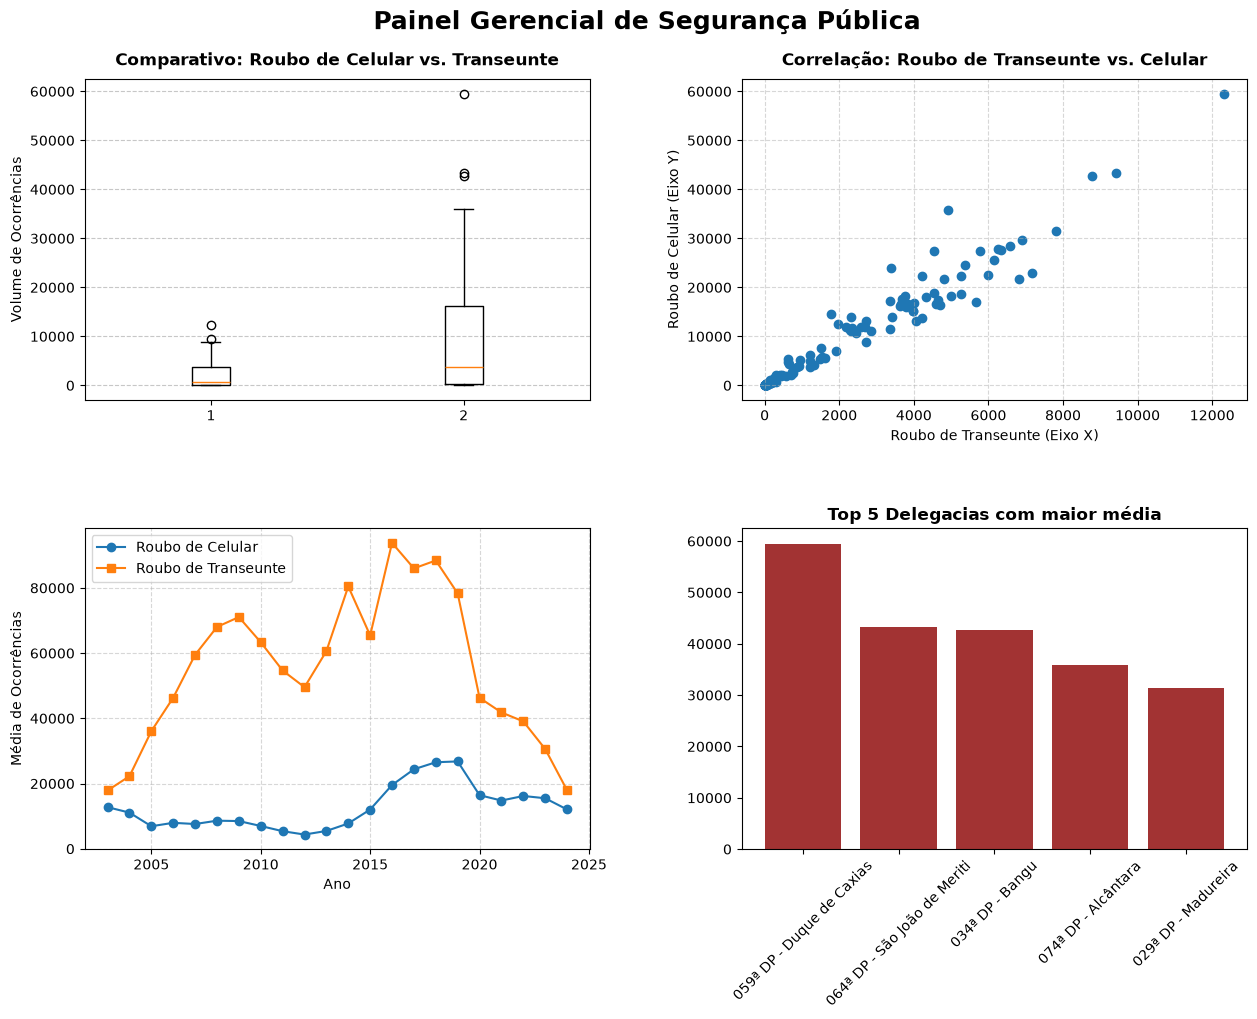

In [61]:
plt.subplots(2, 2, figsize=(15, 10))

plt.subplots_adjust(hspace=0.4, wspace=0.3)

plt.suptitle("Painel Gerencial de Segurança Pública", fontsize=18, fontweight='bold', y=0.95)
plt.subplot(2, 2, 1)

plt.boxplot([df_roubo_celular_por_dp['roubo_celular'], df_roubo_transeunte_por_dp['roubo_transeunte']])

plt.title("Comparativo: Roubo de Celular vs. Transeunte", fontsize=12, fontweight='bold', pad=10)
plt.xticks(fontsize=10)
plt.ylabel("Volume de Ocorrências", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(2, 2, 2)
plt.scatter(df_roubo_celular_por_dp['roubo_celular'], df_roubo_transeunte_por_dp['roubo_transeunte'])

plt.title("Correlação: Roubo de Transeunte vs. Celular", fontsize=12, fontweight='bold', pad=10)
plt.xlabel("Roubo de Transeunte (Eixo X)", fontsize=10)
plt.ylabel("Roubo de Celular (Eixo Y)", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(2, 2, 3)
plt.plot(df_roubo_celular_por_ano['ano'], df_roubo_celular_por_ano['roubo_celular'], marker='o', label='Roubo de Celular')
plt.plot(df_roubo_transeunte_por_ano['ano'], df_roubo_transeunte_por_ano['roubo_transeunte'], marker='s', label='Roubo de Transeunte')
plt.xlabel("Ano", fontsize=10)
plt.ylabel("Média de Ocorrências", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.subplot(2, 2, 4)
plt.title("Top 5 Delegacias com maior média", fontsize=12, fontweight='bold')
plt.bar(df_roubo_transeunte_decrescente['nome'].head(5), df_roubo_transeunte_decrescente['roubo_transeunte'].head(5), color='darkred', alpha=0.8)
plt.xticks(rotation=45)

plt.show()